# California Home Price Forecasting

This notebook is the runnable final-project demonstration for Stats 170B. It uses the compact selected model data included in this submission folder.

The full project predicts next-year median sale prices for California ZCTA-year records using housing, demographic, school, crime, amenity, and wage features. The final report compares Ridge regression, Random Forest, and XGBoost. To keep this notebook fast and self-contained, it refits the Ridge model on the selected 2012-2022 training data, evaluates it on the 2023 holdout, and displays the saved final metrics for all three models.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

ROOT = Path.cwd()
DATA = ROOT / "data"
OUTPUTS = ROOT / "outputs"

print("Loaded submission files from the current working directory.")

Loaded submission files from the current working directory.


## Load selected train/test data

The included CSVs are the selected 54-feature modeling tables used for the final model comparison. The training split uses 2012-2022 records. The holdout uses 2023 records, where the target is the observed 2024 median sale price.

In [2]:
train = pd.read_csv(DATA / "phase2_selected_train_2012_2022.csv")
test = pd.read_csv(DATA / "phase2_selected_test_2023.csv")
metrics_saved = pd.read_csv(DATA / "phase2_holdout_relative_error_metrics.csv")

with open(DATA / "phase2_selected_features.json") as f:
    feature_config = json.load(f)

print("train rows/columns:", train.shape)
print("test rows/columns:", test.shape)
print("selected feature count:", feature_config["selected_feature_count"])

train[["zcta5", "year", "y_next_year_median_sale_price", "annual_median_sale_price"]].head()

train rows/columns: (12530, 59)
test rows/columns: (1138, 59)
selected feature count: 54


,zcta5,year,y_next_year_median_sale_price,annual_median_sale_price
0,90001,2012,232452.609400,188222.653317
1,90002,2012,212702.157598,163361.682243
2,90003,2012,239765.986842,190191.210191
3,90004,2012,758460.614152,523361.077844
4,90005,2012,607322.475570,542278.409091


## Final saved model comparison

These are the final holdout metrics used in the report and poster. Ridge has the lowest MAPE, while Random Forest has the highest dollar-scale R-squared.

In [3]:
display_cols = [
    "model", "train_years", "test_year", "target_year", "rows",
    "mape_pct", "median_ape_pct", "r2_dollars", "r2_log_change"
]
metrics_saved[display_cols].sort_values("mape_pct")

,model,train_years,test_year,target_year,rows,mape_pct,median_ape_pct,r2_dollars,r2_log_change
0,ridge_linear_regression,2012-2022,2023,2024,1138.0,6.235526,4.175416,0.954970,-0.151660
1,random_forest,2012-2022,2023,2024,1138.0,6.725603,5.207498,0.965744,-0.204580
2,xgboost,2012-2022,2023,2024,1138.0,6.800516,5.414154,0.963498,-0.209636


## Refit the Ridge model on the compact selected data

The model predicts next-year log price change. We convert the predicted log change back to a 2024 dollar price by multiplying the 2023 median sale price by `exp(predicted_log_change)`.

In [4]:
pre = feature_config["preprocessing"]
numeric_features = pre["numeric"] + pre["boolean"]
categorical_features = pre["categorical"]
all_features = numeric_features + categorical_features

def coerce_boolean_columns(df, columns):
    out = df.copy()
    mapping = {True: 1, False: 0, "True": 1, "False": 0, "true": 1, "false": 0, 1: 1, 0: 0}
    for col in columns:
        out[col] = out[col].map(mapping).fillna(0).astype(float)
    return out

train_model = coerce_boolean_columns(train, pre["boolean"])
test_model = coerce_boolean_columns(test, pre["boolean"])

try:
    cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", cat_encoder),
        ]), categorical_features),
    ],
    remainder="drop",
)

ridge_alpha = float(metrics_saved.loc[metrics_saved["model"].eq("ridge_linear_regression"), "ridge_alpha"].iloc[0])
ridge_model = Pipeline([
    ("preprocess", preprocessor),
    ("ridge", Ridge(alpha=ridge_alpha)),
])

target_log = feature_config["target_columns"]["log_change"]
target_price = feature_config["target_columns"]["price"]

ridge_model.fit(train_model[all_features], train_model[target_log])
pred_log_change = ridge_model.predict(test_model[all_features])
pred_price = test_model["annual_median_sale_price"].to_numpy() * np.exp(pred_log_change)
actual_price = test_model[target_price].to_numpy()

ape_pct = np.abs((actual_price - pred_price) / actual_price) * 100
ridge_demo_metrics = pd.DataFrame([
    {
        "model": "ridge_demo_refit",
        "rows": len(test_model),
        "mape_pct": ape_pct.mean(),
        "median_ape_pct": np.median(ape_pct),
        "r2_dollars": r2_score(actual_price, pred_price),
    }
])
ridge_demo_metrics

,model,rows,mape_pct,median_ape_pct,r2_dollars
0,ridge_demo_refit,1138,6.577939,4.778824,0.9519


## Predicted versus actual prices

The diagonal line represents perfect prediction. Points near the line indicate that the model is recovering 2024 price levels well.

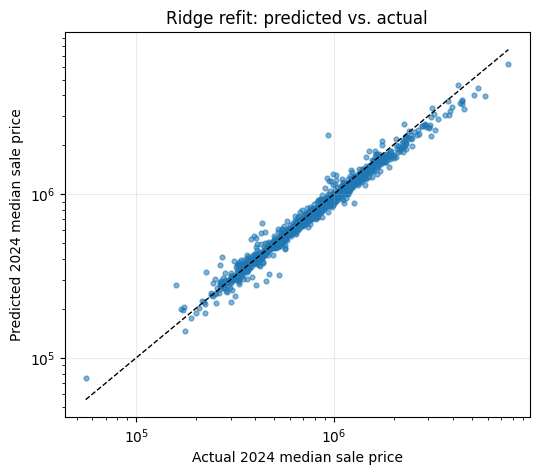

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(actual_price, pred_price, s=12, alpha=0.55)
lo = min(actual_price.min(), pred_price.min())
hi = max(actual_price.max(), pred_price.max())
ax.plot([lo, hi], [lo, hi], linestyle="--", color="black", linewidth=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual 2024 median sale price")
ax.set_ylabel("Predicted 2024 median sale price")
ax.set_title("Ridge refit: predicted vs. actual")
ax.grid(True, alpha=0.25)
plt.show()

## Example predictions

The table below shows a few accurate predictions and a few high-error predictions from the holdout. These examples illustrate how the model can be used on ZCTA-year rows and where the model still struggles.

In [6]:
examples = test_model[["zcta5", "year", "parent_metro_region", "annual_median_sale_price", target_price]].copy()
examples["predicted_2024_price"] = pred_price
examples["absolute_percentage_error"] = ape_pct
examples = examples.rename(columns={
    "annual_median_sale_price": "current_2023_price",
    target_price: "actual_2024_price",
})

good = examples.sort_values("absolute_percentage_error").head(5)
hard = examples.sort_values("absolute_percentage_error", ascending=False).head(5)
pd.concat({"lowest_error_examples": good, "highest_error_examples": hard}).round(2)

zcta5  year parent_metro_region  current_2023_price  actual_2024_price  \
lowest_error_examples  513   93004  2023          Oxnard, CA           825007.08          847501.53   
                       335   92231  2023       El Centro, CA           353109.38          361564.44   
                       1078  95826  2023      Sacramento, CA           464581.11          481255.41   
                       817   94706  2023         Oakland, CA          1121267.57         1065484.25   
                       1034  95661  2023      Sacramento, CA           682109.43          691821.88   
highest_error_examples 965   95441  2023      Santa Rosa, CA          2381911.43          933382.35   
                       550   93252  2023          Oxnard, CA           266858.89          158686.05   
                       1041  95681  2023      Sacramento, CA           631785.71          430428.57   
                       1005  95573  2023          Eureka, CA           393289.16          271532.05   
                       607   93518  2023     Bakersfield, CA           322391.30          226379.31   

                             predicted_2024_price  absolute_percentage_error  
lowest_error_examples  513              847547.39                       0.01  
                       335              361537.15                       0.01  
                       1078             481302.09                       0.01  
                       817             1065369.11                       0.01  
                       1034             691919.74                       0.01  
highest_error_examples 965             2304604.59                     146.91  
                       550              277785.68                      75.05  
                       1041             666536.51                      54.85  
                       1005             413530.71                      52.30  
                       607              332760.87                      46.99

## Feature interpretation outputs

The files in `outputs/` are saved interpretation tables from the full final model runs. They show that feature importance is model-specific: the linear model and tree models use the same selected feature schema differently.

In [7]:
ridge_coef = pd.read_csv(OUTPUTS / "linear_regression_coefficients_by_feature.csv")
rf_importance = pd.read_csv(OUTPUTS / "random_forest_permutation_importance.csv")
xgb_importance = pd.read_csv(OUTPUTS / "xgboost_permutation_importance.csv")

print("Ridge top coefficient groups")
display(ridge_coef.sort_values("max_abs_coefficient", ascending=False).head(6))

print("Random Forest top permutation-importance features")
display(rf_importance.sort_values("importance_mean_log_mae", ascending=False).head(6))

print("XGBoost top permutation-importance features")
display(xgb_importance.sort_values("importance_mean_log_mae", ascending=False).head(6))

Ridge top coefficient groups


,model,feature,source_group,max_abs_coefficient,sum_abs_coefficient,coefficient_terms
0,ols_linear_regression,parent_metro_region,listings,0.169551,0.690093,36
1,ols_linear_regression,assessment_type,school_quality,0.149683,0.195865,2
53,ridge_linear_regression,assessment_type,school_quality,0.139823,0.183078,2
2,ols_linear_regression,total_students_tested_unreliable,school_quality,0.123849,0.123849,1
54,ridge_linear_regression,total_students_tested_unreliable,school_quality,0.105404,0.105404,1
55,ridge_linear_regression,parent_metro_region,listings,0.103976,0.420616,36


Random Forest top permutation-importance features


,feature,importance_mean_log_mae,importance_std_log_mae,source_group
0,annual_off_market_in_two_weeks,0.000926,0.000121,listings
1,annual_months_of_supply_est,0.000908,0.000078,listings
2,annual_median_sale_price,0.000884,0.000191,listings
3,annual_homes_sold,0.000760,0.000109,listings
4,born_other_state_25plus_bachelors_or_higher_share,0.000376,0.000087,demographics
5,race_some_other_race_alone_share,0.000243,0.000049,demographics


XGBoost top permutation-importance features


,feature,importance_mean_log_mae,importance_std_log_mae,source_group
0,annual_off_market_in_two_weeks,0.001797,0.000230,listings
1,annual_median_sale_price,0.001563,0.000219,listings
2,annual_months_of_supply_est,0.000987,0.000109,listings
3,annual_homes_sold,0.000628,0.000092,listings
4,parent_metro_region,0.000503,0.000071,listings
5,log_median_household_income,0.000459,0.000059,demographics


## Conclusion

This compact reproduction confirms the main project result: public ZCTA-level data can support useful next-year price forecasts, with Ridge giving the best average percentage error on the final holdout. More complex tree models were useful for comparison and interpretation but did not materially improve MAPE in the final evaluation.